This notebook demonstrates the ScopeSim implementation of the MICADO IFU mode. The IFU mode has only recently been added to MICADO. It will consist of an image slicer with 32 slices with an on-sky width of 0.012 arcsec and a length of 0.45 arcsec. The slices are rearranged before the light is passed through the standard MICADO spectrograph, which results in 32 non-overlapping traces for each spectral order. The IFU will be offered in HK only, so that there are two orders (ORDER_3_1 and ORDER_4_1).

In [15]:
from matplotlib import pyplot as plt
from astropy import units as u

We start by importing ScopeSim and pointing it to the relevant instrument packages. Most users should download the latest version of the instrument packages.

In [4]:
import scopesim as sim

In [5]:
# Edit this path if you have a custom install directory, otherwise comment it out. [For ReadTheDocs only]
sim.link_irdb("../../../../")

# If you want/need to download the instrument packages uncomment the following line
#sim.download_packages(["Armazones", "ELT", "METIS"])

The following command gives the versions of python packages that are used by Scopesim as well as of instrument packages (called IRDB packages). We ask to include the output of this command in any communication with us, in particular in bug reports.

In [6]:
sim.bug_report()

Python:
3.12.9 (main, Feb  5 2025, 01:31:18) [GCC 14.2.0]

Installed Python packages:
           anisocado: 0.5.0
         astar-utils: 0.5.2
             astropy: 6.1.7
      beautifulsoup4: 4.13.3
            docutils: 0.21.2
               httpx: 0.28.1
                lxml: 6.0.2
          matplotlib: 3.10.8
      more-itertools: 10.2.0
               numpy: 2.2.6
           packaging: 25.0
               pooch: 1.9.0
              pyyaml: 6.0.3
               scipy: 1.17.0
            scopesim: 0.11.4a7
       scopesim_data: could not be loaded.
  scopesim_templates: 0.8.2a2
         skycalc-ipy: 0.7.0
             synphot: 1.6.1
                tqdm: 4.67.3

Installed IRDB packages:
       HARMONI: version number not available.
         HAWKI: version number not available.
           VLT: version number not available.
        OSIRIS: version number not available.
           ELT: version number not available.
       LaPalma: version number not available.
         VISIR: version nu

# Setting up the instrument
We set up MICADO to use the IFU in SCAO (stand-alone) mode.

In [7]:
cmds = sim.UserCommands(use_instrument="MICADO", set_modes=["SCAO", "IFU"])

astar.scopesim.commands.user_commands - Mode 'IFU' is still in experimental stage, results may not be representative of physical instrument.


In [10]:
micado = sim.OpticalTrain(cmds)

In [12]:
micado.effects.show_in_notebook()

idx,element,name,class,included
0,armazones,skycalc_atmosphere,SkycalcTERCurve,True
1,ELT,telescope_reflection,SurfaceList,True
2,ELT,telescope_fits_keywords,ExtraFitsKeywords,True
3,MICADO,micado_static_surfaces,SurfaceList,True
4,MICADO,micado_ncpas_psf,NonCommonPathAberration,True
5,MICADO,slit_wheel : [False],SlitWheel,False
6,MICADO,filter_wheel_1 : [Spec_HK],FilterWheel,True
7,MICADO,filter_wheel_2 : [open],FilterWheel,True
8,MICADO,pupil_wheel : [open],FilterWheel,True
9,MICADO_DET,full_detector_array,DetectorList,False


# Define a source and simulate

In [17]:
star = sim.source.source_templates.star(x=0, y=0, flux=15*u.mag)

To simulate the full MICADO field, we need to switch two effects:

In [37]:
micado["full_detector_array"].include = True
micado["detector_window"].include = False

In [42]:
micado.observe(star)

 FOVs:   0%|          | 0/2 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/3 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - Interpolating PSF onto (3750, 193, 225) cube


 PSF slices:   0%|          | 0/3750 [00:00<?, ?it/s]

 Spectral Traces:   0%|          | 0/64 [00:00<?, ?it/s]

...

 FOV effects:   0%|          | 0/3 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - Interpolating PSF onto (6250, 193, 225) cube


 PSF slices:   0%|          | 0/6250 [00:00<?, ?it/s]

 Spectral Traces:   0%|          | 0/64 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopesim.effects.spectral_trace_list_utils - WARNING: xlim_mm is None
astar.scopes

In [43]:
hdul = micado.readout(dit=100, ndit=10)[0]

astar.scopesim.detector.detector_manager - Extracting from 9 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.electronic.electrons - Applying gain 1
astar.scopesim.effects.fits_headers - WARNING: #exposure_action.include not found


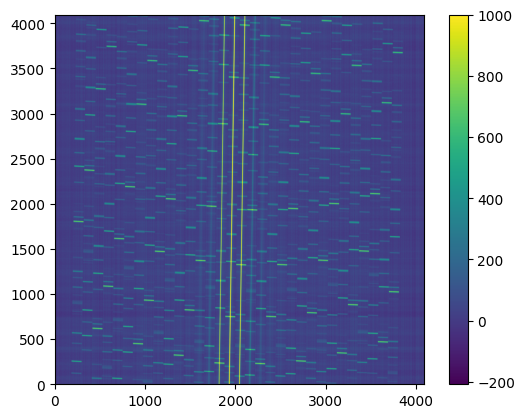

In [47]:
plt.imshow(hdul[5].data, origin='lower', vmax=1000)
plt.colorbar()

To view the entire detector array we recommend saving to disk (`hdul.writeto("your_file.fits")`) and using `ds9`. Open the file with `File -> Open as -> Mosaic WCS` and select `WCS d` to arrange the nine detectors correctly in the detector plane. 

# Rectification (not yet available)